In [15]:
!pip install ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q
!pip install faiss-cpu pillow numpy matplotlib -q

  Preparing metadata (setup.py) ... done


In [16]:
import os
import numpy as np
import faiss
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [4]:
IMAGE_DIRS = [
    "/content/drive/MyDrive/Jewellery_Data/ring/",
    "/content/drive/MyDrive/Jewellery_Data/necklace/"
]

In [18]:
image_paths = []

for folder in IMAGE_DIRS:
    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]
    image_paths.extend(files)

print(f"Total images found: {len(image_paths)}")

Total images found: 490


In [19]:
def embed_image(image_path):
    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = model.encode_image(image)
    return embedding.cpu().numpy().astype("float32")

def embed_text(text):
    tokens = clip.tokenize([text]).to(device)
    with torch.no_grad():
        embedding = model.encode_text(tokens)
    return embedding.cpu().numpy().astype("float32")

In [20]:
image_embeddings = []

for path in image_paths:
    emb = embed_image(path)
    image_embeddings.append(emb)

image_embeddings = np.vstack(image_embeddings)
print("Embedding shape:", image_embeddings.shape)

# Normalize for cosine similarity
faiss.normalize_L2(image_embeddings)

Embedding shape: (490, 512)


In [21]:
dim = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(image_embeddings)

print("Total indexed images:", index.ntotal)

Total indexed images: 490


In [22]:
def plot_results(results, k=10, title=None):
    plt.figure(figsize=(18, 4))

    for i, (path, score) in enumerate(results[:k]):
        img = Image.open(path)

        plt.subplot(1, k, i + 1)
        plt.imshow(img)
        plt.axis("off")

        img_name = os.path.basename(path)
        plt.title(f"{img_name}\nScore: {score:.3f}", fontsize=9)

    if title:
        plt.suptitle(title, fontsize=14)

    plt.show()

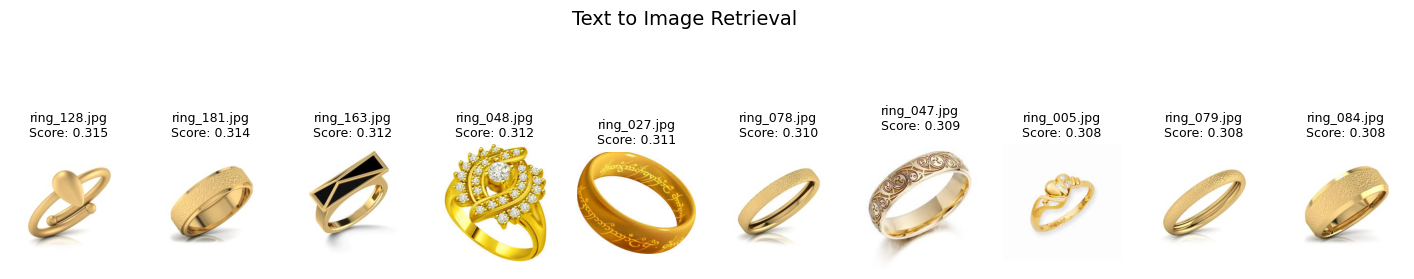

In [23]:
query = "gold ring"

query_embedding = embed_text(query)
faiss.normalize_L2(query_embedding)

k = 10
scores, indices = index.search(query_embedding, k)

text_results = [
    (image_paths[i], scores[0][rank])
    for rank, i in enumerate(indices[0])
]

plot_results(
    text_results,
    k=k,
    title="Text to Image Retrieval"
)

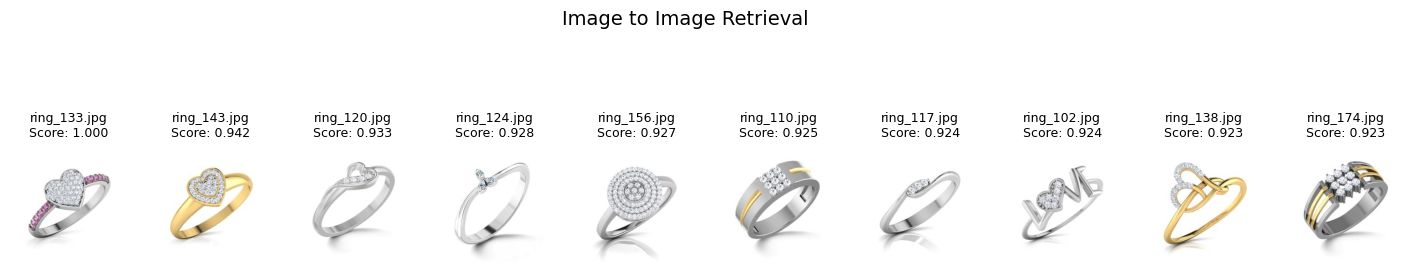

In [24]:
query_image = "/content/drive/MyDrive/Jewellery_Data/ring/ring_133.jpg"

query_emb = embed_image(query_image)
faiss.normalize_L2(query_emb)

scores, indices = index.search(query_emb, k)

image_results = [
    (image_paths[i], scores[0][rank])
    for rank, i in enumerate(indices[0])
]

plot_results(
    image_results,
    k=k,
    title="Image to Image Retrieval"
)